Tokens: ['In', 'a', 'quiet', 'corner', 'of', 'the', 'bustling', 'city,', 'a', 'small', 'coffee', 'shop', 'offered', 'warmth', 'and', 'comfort', 'to', 'every', 'visitor.']


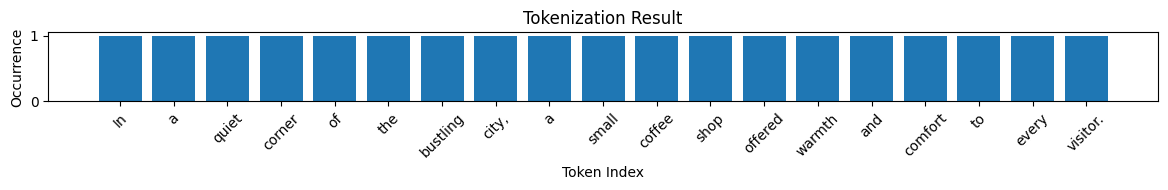

In [1]:
import matplotlib.pyplot as plt

# Phase 1: Input sentence and tokenize
sentence = "In a quiet corner of the bustling city, a small coffee shop offered warmth and comfort to every visitor."
# Tokenize by splitting on spaces (punctuation remains attached to words)
tokens = sentence.split()
print("Tokens:", tokens)

# Visualize the tokenization result with a bar chart
plt.figure(figsize=(12, 2))
plt.bar(range(len(tokens)), [1] * len(tokens), tick_label=tokens)
plt.title("Tokenization Result")
plt.xlabel("Token Index")
plt.ylabel("Occurrence")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Embeddings shape: (19, 16)


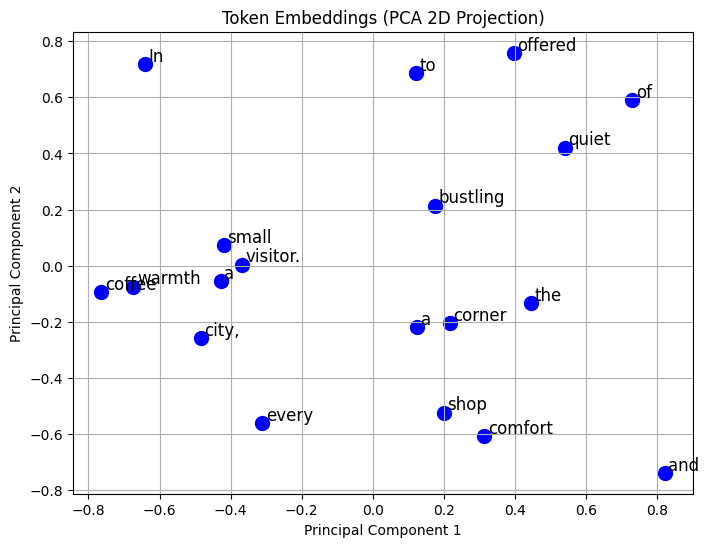

In [2]:
import numpy as np
from sklearn.decomposition import PCA

# Phase 2: Generate random embeddings for each token
embedding_dim = 16  # Set embedding dimension
embeddings = np.random.rand(len(tokens), embedding_dim)
print("Embeddings shape:", embeddings.shape)

# Use PCA to reduce embeddings to 2 dimensions for visualization
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=100, color='blue')
for i, token in enumerate(tokens):
    plt.text(embeddings_2d[i, 0] + 0.01, embeddings_2d[i, 1] + 0.01, token, fontsize=12)
plt.title("Token Embeddings (PCA 2D Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


Positional Encoding shape: (19, 16)


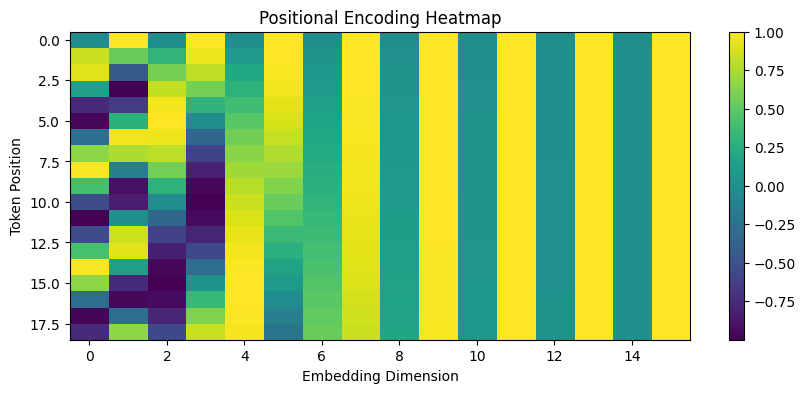

In [3]:
def get_positional_encoding(seq_len, d_model):
    """
    Compute the positional encoding matrix of shape (seq_len, d_model)
    using the formulas from "Attention Is All You Need".
    """
    pos_encoding = np.zeros((seq_len, d_model))
    for pos in range(seq_len):
        for i in range(d_model):
            angle = pos / np.power(10000, (2 * (i // 2)) / d_model)
            if i % 2 == 0:
                pos_encoding[pos, i] = np.sin(angle)
            else:
                pos_encoding[pos, i] = np.cos(angle)
    return pos_encoding

# Phase 3: Calculate positional encoding for each token
pos_encoding = get_positional_encoding(len(tokens), embedding_dim)
print("Positional Encoding shape:", pos_encoding.shape)

# Visualize the positional encoding matrix using a heatmap
plt.figure(figsize=(10, 4))
plt.imshow(pos_encoding, cmap='viridis', aspect='auto')
plt.colorbar()
plt.xlabel("Embedding Dimension")
plt.ylabel("Token Position")
plt.title("Positional Encoding Heatmap")
plt.show()


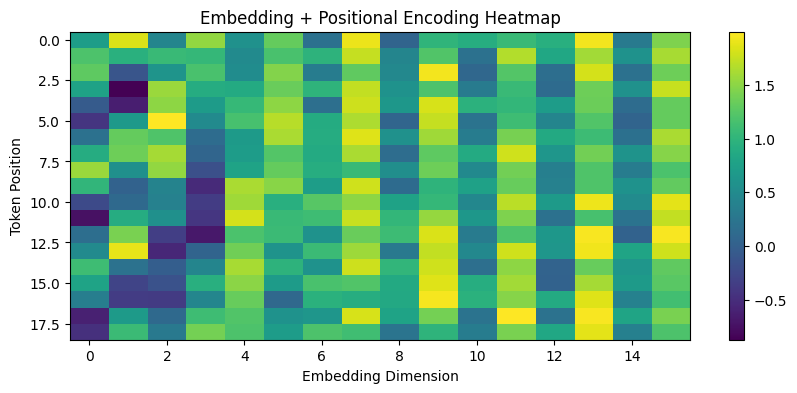

In [4]:
# Optional: Combine token embeddings with positional encoding
embeddings_with_pos = embeddings + pos_encoding

plt.figure(figsize=(10, 4))
plt.imshow(embeddings_with_pos, cmap='viridis', aspect='auto')
plt.colorbar()
plt.xlabel("Embedding Dimension")
plt.ylabel("Token Position")
plt.title("Embedding + Positional Encoding Heatmap")
plt.show()
